In [1]:
# Task 1: Data Understanding 
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Load the dataset using Pandas
df = pd.read_csv('cleaned_global_water_consumption.csv')

# Print First 5 rows
print("\nFirst 5 rows")
df.head()


First 5 rows


,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%),Water Scarcity Level
0,Argentina,2000,481.490000,235.431429,48.550000,20.844286,30.100000,1288.698571,3.255714,Moderate
1,Argentina,2001,455.063000,299.551000,48.465000,26.943000,22.550000,1371.729000,3.120000,Moderate
2,Argentina,2002,482.749231,340.124615,50.375385,29.042308,23.349231,1590.305385,2.733846,Moderate
3,Argentina,2003,452.660000,326.756667,49.086667,30.476000,24.440000,1816.012667,2.708000,Moderate
4,Argentina,2004,634.566000,230.346000,38.670000,36.670000,23.924000,815.998000,1.902000,Moderate


In [2]:
# Print last 5 rows
print("\nLast 5 rows")
df.tail()


Last 5 rows


,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%),Water Scarcity Level
495,USA,2020,418.097,292.9700,47.448,25.2660,27.5380,1510.662,2.4310,Moderate
496,USA,2021,572.094,275.9780,46.195,32.2230,26.7200,754.615,2.6280,Moderate
497,USA,2022,440.978,292.0390,54.810,30.9180,22.6380,2119.898,2.8710,Moderate
498,USA,2023,566.865,261.1975,62.945,25.2075,21.6325,1439.155,1.5975,Moderate
499,USA,2024,249.485,186.3740,51.386,24.7690,27.6770,1771.199,1.6380,High


In [127]:
# Print dataset shape
print("\nDataset Shape: ",df.shape)

# Print column names
print("\nColumn Names")
print(df.columns)


Dataset Shape:  (500, 10)

Column Names
Index(['Country', 'Year', 'Total Water Consumption (Billion Cubic Meters)',
       'Per Capita Water Use (Liters per Day)', 'Agricultural Water Use (%)',
       'Industrial Water Use (%)', 'Household Water Use (%)',
       'Rainfall Impact (Annual Precipitation in mm)',
       'Groundwater Depletion Rate (%)', 'Water Scarcity Level'],
      dtype='object')


In [3]:
# Identify

# Select quantitative (numerical) columns
quantitative_cols = df.select_dtypes(include=['int64','float64'])

print("\nQuantitative Columns")
print(quantitative_cols.columns)

# Select qualitative (categorical) columns
qualitative_cols = df.select_dtypes(include=['object'])

print("\nQualitative (Categorical) Columns")
print(qualitative_cols.columns)


Quantitative Columns
Index(['Year', 'Total Water Consumption (Billion Cubic Meters)',
       'Per Capita Water Use (Liters per Day)', 'Agricultural Water Use (%)',
       'Industrial Water Use (%)', 'Household Water Use (%)',
       'Rainfall Impact (Annual Precipitation in mm)',
       'Groundwater Depletion Rate (%)'],
      dtype='object')

Qualitative (Categorical) Columns
Index(['Country', 'Water Scarcity Level'], dtype='object')


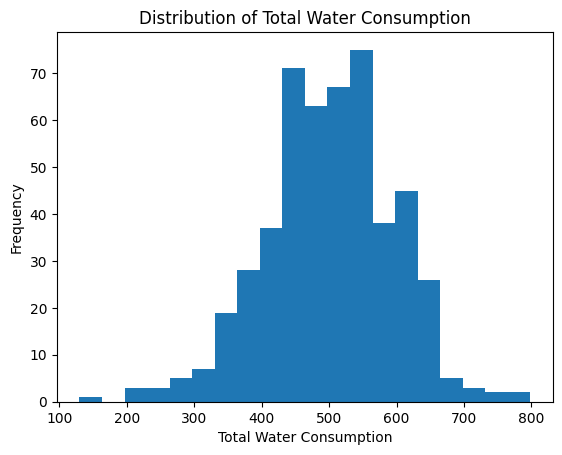

In [5]:
# Task 2: Exploratory Data Analysis (EDA)
# 1. Univariate Analysis

import matplotlib.pyplot as plt

plt.hist(df['Total Water Consumption (Billion Cubic Meters)'], bins=20)
plt.title("Distribution of Total Water Consumption")
plt.xlabel("Total Water Consumption")
plt.ylabel("Frequency")
plt.show()

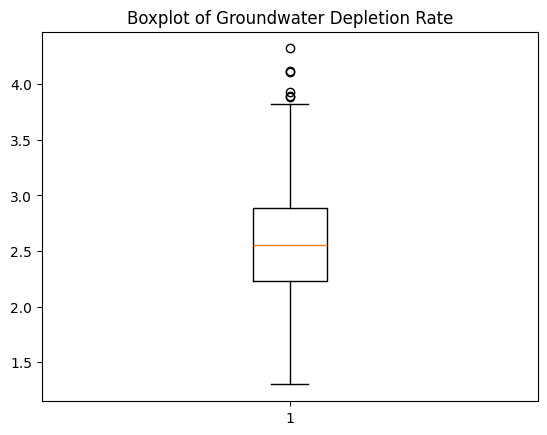

In [6]:
# Boxplot (Groundwater Depletion)
plt.boxplot(df['Groundwater Depletion Rate (%)'])
plt.title("Boxplot of Groundwater Depletion Rate")
plt.show()

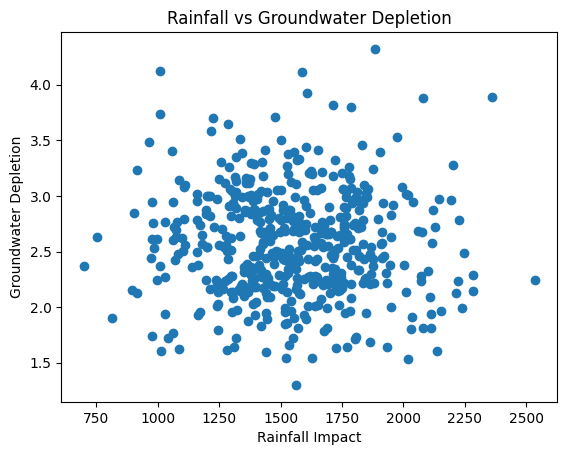

In [7]:
# Bivariate Analysis
# Rainfall vs Groundwater
plt.scatter(df['Rainfall Impact (Annual Precipitation in mm)'],
            df['Groundwater Depletion Rate (%)'])

plt.xlabel("Rainfall Impact")
plt.ylabel("Groundwater Depletion")
plt.title("Rainfall vs Groundwater Depletion")
plt.show()

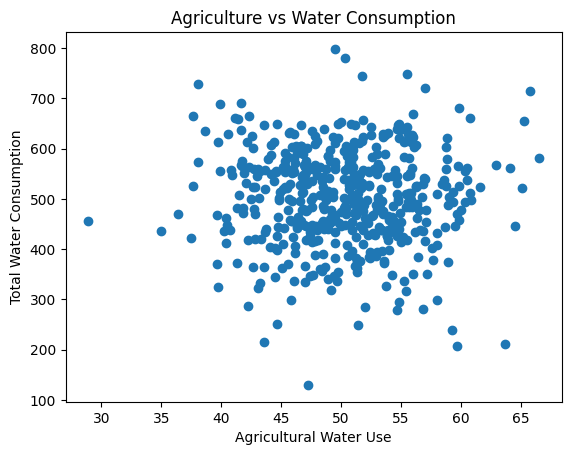

In [10]:
# Agriculture vs Total Consumption
plt.scatter(df['Agricultural Water Use (%)'],
            df['Total Water Consumption (Billion Cubic Meters)'])

plt.xlabel("Agricultural Water Use")
plt.ylabel("Total Water Consumption")
plt.title("Agriculture vs Water Consumption")
plt.show()

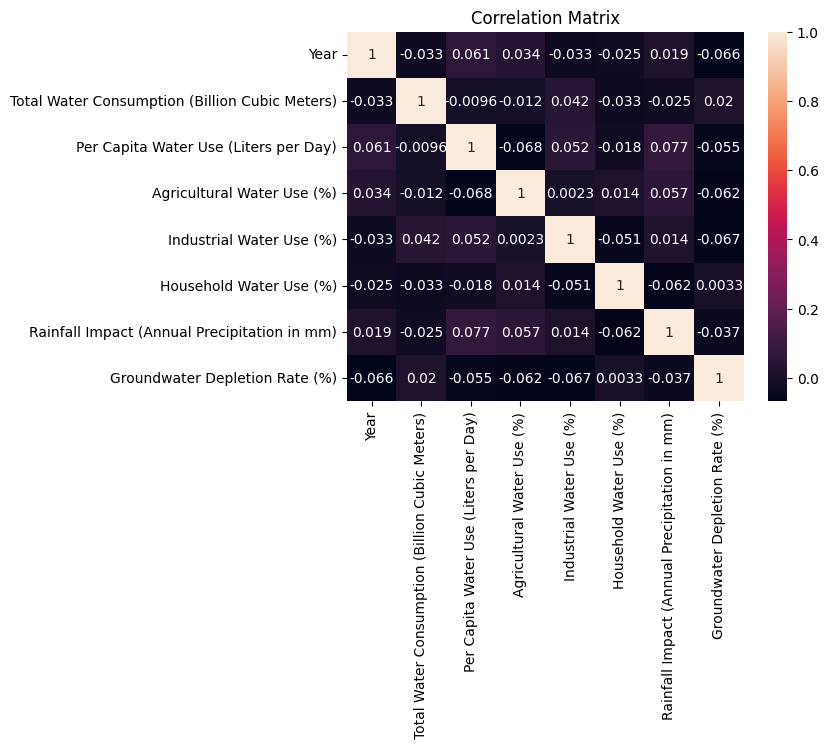

In [11]:
# Correlation Matrix
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [13]:
# Task 3: Handling Missing Data and Outliers
# Check missing values in each column
# isnull() checks for missing values
# sum() counts total missing values column-wise
print(df.isnull().sum())

Country                                           0
Year                                              0
Total Water Consumption (Billion Cubic Meters)    0
Per Capita Water Use (Liters per Day)             0
Agricultural Water Use (%)                        0
Industrial Water Use (%)                          0
Household Water Use (%)                           0
Rainfall Impact (Annual Precipitation in mm)      0
Groundwater Depletion Rate (%)                    0
Water Scarcity Level                              0
dtype: int64


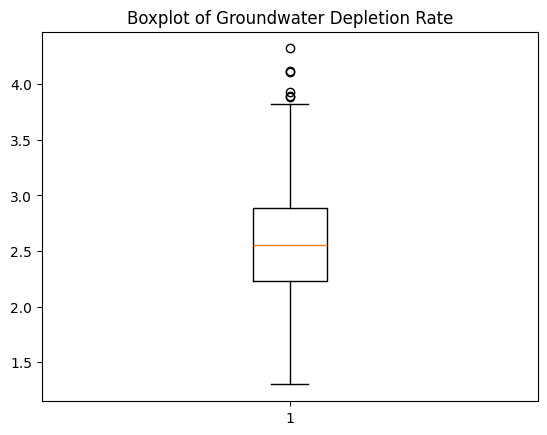

In [14]:
# Detect Outliers using Boxplots
plt.boxplot(df['Groundwater Depletion Rate (%)'])
plt.title("Boxplot of Groundwater Depletion Rate")
plt.show()

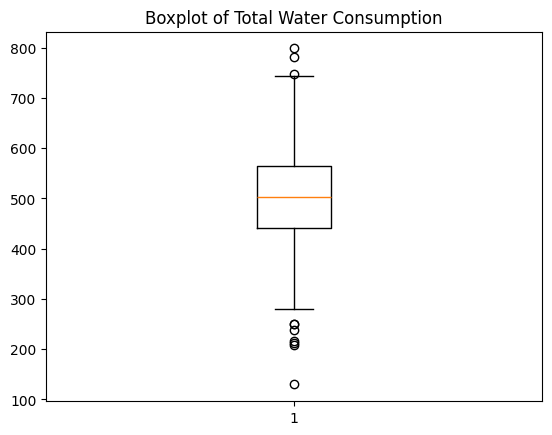

In [15]:
# Total Water Consumption
plt.boxplot(df['Total Water Consumption (Billion Cubic Meters)'])
plt.title("Boxplot of Total Water Consumption")
plt.show()

Shape before removing outliers: (500, 10)
Shape after removing outliers: (494, 10)


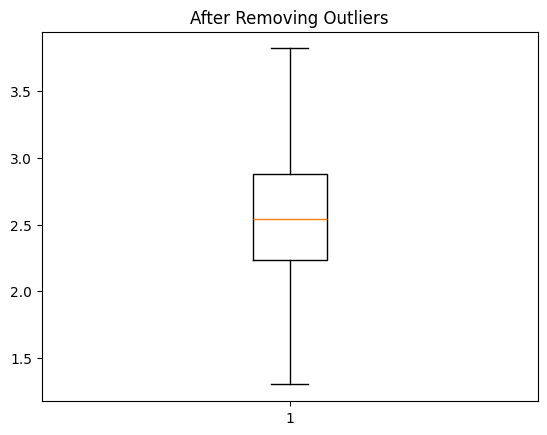

In [16]:
# Remove Outliers (IQR Method)

# Shape before removing outliers
print("Shape before removing outliers:", df.shape)
# Calculate first quartile (25%)
Q1 = df['Groundwater Depletion Rate (%)'].quantile(0.25)
# Calculate third quartile (75%)
Q3 = df['Groundwater Depletion Rate (%)'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define lower and upper limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers from dataset
df = df[(df['Groundwater Depletion Rate (%)'] >= lower_bound) & 
        (df['Groundwater Depletion Rate (%)'] <= upper_bound)]

# Shape after removing outliers
print("Shape after removing outliers:", df.shape)

plt.boxplot(df['Groundwater Depletion Rate (%)'])
plt.title("After Removing Outliers")
plt.show()

In [18]:
# Task 4: Spread of Data
# Statistical Measures (Mean, Median, Std, Skewness, Kurtosis)
cols = [
    'Total Water Consumption (Billion Cubic Meters)',
    'Groundwater Depletion Rate (%)',
    'Rainfall Impact (Annual Precipitation in mm)'
]

for col in cols:
    print(f"\nColumn: {col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Std Dev:", df[col].std())
    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurtosis())


Column: Total Water Consumption (Billion Cubic Meters)
Mean: 501.56013108643725
Median: 502.19715384999995
Std Dev: 96.05337200773269
Skewness: -0.25800443711391347
Kurtosis: 0.5057750795324294

Column: Groundwater Depletion Rate (%)
Mean: 2.55516946067004
Median: 2.544404762
Std Dev: 0.45481181980154933
Skewness: 0.07929418186079266
Kurtosis: -0.28035142285263825

Column: Rainfall Impact (Annual Precipitation in mm)
Mean: 1542.2762405589067
Median: 1534.0529285
Std Dev: 289.84076202946403
Skewness: 0.10726360977397455
Kurtosis: 0.045300394167105296


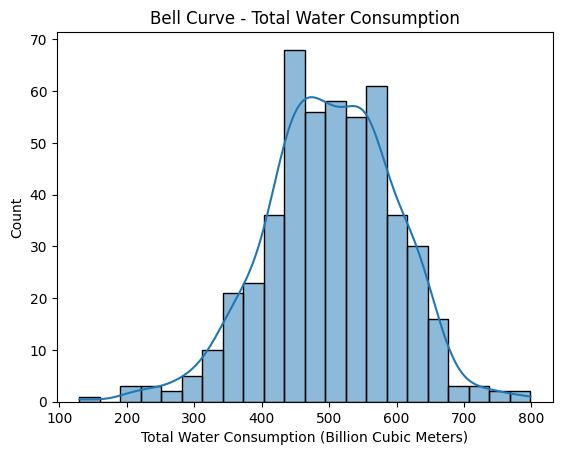

In [19]:
import seaborn as sns

# Bell curve for one important column
sns.histplot(df['Total Water Consumption (Billion Cubic Meters)'], kde=True)
plt.title("Bell Curve - Total Water Consumption")
plt.show()

In [20]:
# Calculate
# Interpretation of Statistical Measures

#  Mean vs Median
# If Mean ≈ Median → data is normal
# If Mean > Median → right skewed
# If Mean < Median → left skewed

#  Standard Deviation
# Low → data is consistent
# High → data is spread out

#  Skewness
# Positive → high values dominate
# Negative → low values dominate

#  Kurtosis
# High → more outliers/extreme values
# Low → flatter distribution

In [21]:
# Task 5: Automating EDA using Python

# Reusable EDA function
def eda_summary(data):
    print("Shape:", data.shape)
    
    print("\nInfo:")
    data.info()
    
    print("\nStatistical Summary:")
    print(data.describe())
    
    print("\nMissing Values:")
    print(data.isnull().sum())
    
    print("\nCorrelation:")
    print(data.corr(numeric_only=True))

eda_summary(df)

Shape: (494, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 494 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Country                                         494 non-null    object 
 1   Year                                            494 non-null    int64  
 2   Total Water Consumption (Billion Cubic Meters)  494 non-null    float64
 3   Per Capita Water Use (Liters per Day)           494 non-null    float64
 4   Agricultural Water Use (%)                      494 non-null    float64
 5   Industrial Water Use (%)                        494 non-null    float64
 6   Household Water Use (%)                         494 non-null    float64
 7   Rainfall Impact (Annual Precipitation in mm)    494 non-null    float64
 8   Groundwater Depletion Rate (%)                  494 non-null    float64
 9   Water Scarcity Level    

In [22]:
# Task 6: Regression / Task 7: Supervised Learning Preparation
# Encoding Categorical Target Variable

# Dependent Variable (Target) Water Scarcity Level
# Convert to numeric:
from sklearn.preprocessing import LabelEncoder

# Create encoder object
le = LabelEncoder()

# Convert 'Water Scarcity Level' from text to numbers
df['Water Scarcity Level'] = le.fit_transform(df['Water Scarcity Level'])

In [23]:
# Independent Variables 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Features
# Define independent variables (features)
X = df[[
    'Groundwater Depletion Rate (%)',
    'Rainfall Impact (Annual Precipitation in mm)',
    'Agricultural Water Use (%)'
]]

# Define dependent variable (target)
y = df['Water Scarcity Level']

In [24]:
# Task 7: Supervised Learning - Classification Model
# Train-Test Split, Model Training and Prediction
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train model using training data
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

In [25]:
# Task 8: Regression Models

from sklearn.linear_model import LinearRegression

# Simple Linear Regression (1 feature)
X_simple = df[['Groundwater Depletion Rate (%)']]
y_simple = df['Total Water Consumption (Billion Cubic Meters)']

model_simple = LinearRegression()
model_simple.fit(X_simple, y_simple)

print("Simple Linear Regression Done")

# Multiple Linear Regression
X_multi = df[
    [
        'Groundwater Depletion Rate (%)',
        'Rainfall Impact (Annual Precipitation in mm)',
        'Agricultural Water Use (%)'
    ]
]

y_multi = df['Total Water Consumption (Billion Cubic Meters)']

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

print("Multiple Linear Regression Done")

Simple Linear Regression Done
Multiple Linear Regression Done


In [146]:
# Task 9: Overfitting and Underfitting Analysis

# Overfitting:
# When training accuracy is high but testing accuracy is low

# Underfitting:
# When both training and testing accuracy are low

# In our model:
# Training Accuracy ≈ Testing Accuracy (~72%)

# Conclusion:
# The model is well-fitted and shows good generalization

In [26]:
# Task 10: Classification Task
# Accuracy Calculation

# Calculate accuracy on training data
train_acc = model.score(X_train, y_train)

# Calculate accuracy on testing data
test_acc = model.score(X_test, y_test)

print("Logistic Regression")
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Logistic Regression
Train Accuracy: 0.4
Test Accuracy: 0.40404040404040403


In [27]:
# Task 10: Classification Task
# Confusion Matrix Analysis
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 1  2  1]
 [12  4  8]
 [22 14 35]]


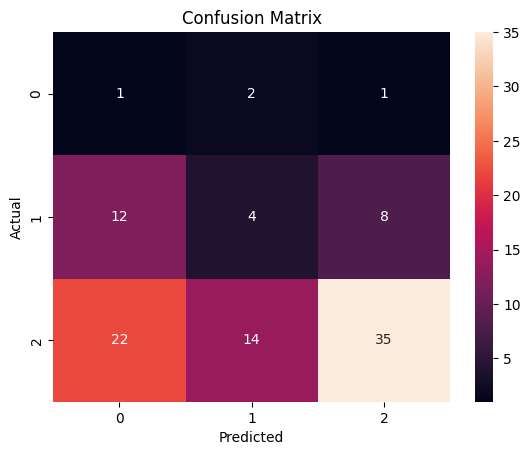

In [28]:
 # Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
# Task 11/12: Model Evaluation (Advanced Metrics)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming y_test and y_pred from regression
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 1.292929292929293
MAE: 0.8282828282828283
R2 Score: -3.31607629427793


In [32]:
# Final Model Testing (New Data Prediction)

# Sample input:
# [Groundwater Depletion, Rainfall, Agricultural Use]

# sample = [[2.5, 1500, 50]]
sample = [[4.0, 800, 65]] #Moderate
# sample = [[1.8, 2200, 40]] #High 

# Predict
prediction = model.predict(sample)

# Convert back to original label
predicted_label = le.inverse_transform(prediction)

print("Predicted Water Scarcity Level:", predicted_label[0])

Predicted Water Scarcity Level: Moderate
